# Глубинное обучение 1 / Введение в глубинное обучение, ФКН ВШЭ

## Домашнее задание 2: сверточный классификатор.

### Общая информация

Оценка после штрафа после мягкого дедлайна вычисляется по формуле $M_{\text{penalty}} = M_{\text{full}} \cdot 0.85^{t/1440}$, где $M_{\text{full}}$ — полная оценка за работу без учета штрафа, а $t$ — время в минутах, прошедшее после мягкого дедлайна (округление до двух цифр после запятой). Таким образом, спустя первые сутки после мягкого дедлайна вы не можете получить оценку выше 8.5, а если сдать через четыре дня после мягкого дедлайна, то ваш максимум — 5.22 балла.

### Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### О задании

В этом задании вам предстоит познакомиться со сверточными сетями и их обучением для классификации изображений с использованием библиотеки PyTorch.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split

## 0. Загрузка данных

Работать мы будем с набором данных [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html). CIFAR10 представляет собой набор изображений 32х32 пикселя, разделенных на 10 классов.

![title](https://pytorch.org/tutorials/_images/cifar10.png)




Набор данных уже определен в <code>torchvision.datasets</code>, так что возьмем его оттуда.



In [2]:
def get_cifar10_data(batch_size, transform_train):
    torch.manual_seed(0)
    np.random.seed(0)

    transform_test = transforms.Compose(
        [transforms.ToTensor(),
         # Переводим цвета пикселей в отрезок [-1, 1]
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )

    # Загружаем данные
    trainvalset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                               download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform_test)

    # В датасете определено разбиение только на train и test,
    # так что валидацию дополнительно выделяем из обучающей выборки
    train_idx, valid_idx = train_test_split(np.arange(len(trainvalset)), test_size=0.3,
                                            shuffle=True, random_state=0)
    trainset = torch.utils.data.Subset(trainvalset, train_idx)
    valset = torch.utils.data.Subset(trainvalset, valid_idx)

    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                               shuffle=True, num_workers=2)
    val_loader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                             shuffle=False, num_workers=2)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                              shuffle=False, num_workers=2)

    return train_loader, val_loader, test_loader


In [3]:
transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64,
                                                         transform_train=transform)

100%|██████████| 170M/170M [01:03<00:00, 2.69MB/s]


Посмотрим на изображения:

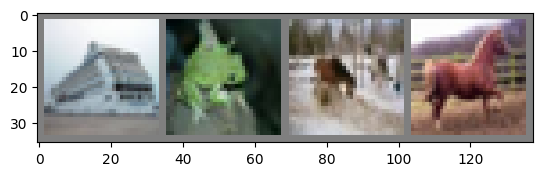

ship frog horse horse


In [4]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(*[classes[labels[i]] for i in range(4)])

## 1. Задание сверточной сети (3 балла)

Теперь нам нужно задать сверточную нейронную сеть, которую мы будем обучать классифицировать изображения.

Используем сеть, основанную на одном блоке архитектуры ResNet.

<img src="https://i.ibb.co/2hg962h/basic-block.png" width="500"/>

__Указания:__

- Все сверточные слои должны иметь 32 выходных канала, а также не должны изменять ширину и высоту изображения.
- Выход блока сократите до размерности 32х4х4, применив average pooling.
- Для получения итоговых логитов, распрямите выход пулинга в вектор из 512 элементов, а затем пропустите его через линейный слой.

**Задание 1.1 (3 балла).**

Определите архитектуру сети соответственно схеме и указаниям выше.

Ключевые слова: <code>Conv2d</code>, <code>BatchNorm2d</code>, <code>AvgPool2d</code>.

In [39]:
n_classes = 10

class BasicBlockNet(nn.Module):
    def __init__(self):
        super().__init__()

        # <your code here>

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.batch1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.batch2 = nn.BatchNorm2d(32)

        self.identity = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=1)

        self.relu2 = nn.ReLU()
        self.adaptavpool = nn.AdaptiveAvgPool2d((4,4)) #делаю так, чтобы вне зависимости от H и W выход был 4x4
        self.flat = nn.Flatten()
        self.lin = nn.Linear(512, 10)

    def forward(self, x):
        ident = self.identity(x)
        out = self.conv1(x) # <your code here>
        out = self.batch1(out)
        out = self.relu1(out)
        out = self.conv2(out)
        out = self.batch2(out)
        out = out + ident
        out = self.relu2(out)
        out = self.adaptavpool(out)
        out = self.flat(out)
        out = self.lin(out)

        return out

In [9]:
net = BasicBlockNet()
net

BasicBlockNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batch1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batch2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (identity): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
  (relu2): ReLU()
  (adaptavpool): AdaptiveAvgPool2d(output_size=(4, 4))
  (flat): Flatten(start_dim=1, end_dim=-1)
  (lin): Linear(in_features=512, out_features=10, bias=True)
)

Проверим, что выход сети имеет корректную размерность:

In [10]:
assert net(torch.zeros((10, 3, 32, 32))).shape == (10, 10)

Чтобы проводить вычисления на GPU, в PyTorch необходимо руками перекладывать объекты, с которыми вы хотите проводить вычисления, на графический ускоритель. Это делается следующим образрм:

In [11]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [12]:
net = net.to(device)

Подключение GPU в google.colab:

**Среда выполнения** -> **Сменить среду выполнения** -> **Аппаратный ускоритель** -> **GPU**

## 2. Обучение и тестирование модели (3 балла)

**Задание 2.1 (2 балла).** Переходим к обучению модели. Заполните пропуски в функциях <code>test</code> и <code>train_epoch</code>. В качестве функции потерь будем использовать [кросс-энтропию](https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html), а в качестве метрики качества accuracy.

In [13]:
def test(model, loader):
    loss_log = []
    acc_log = []
    model.eval()

    with torch.no_grad():
      for data, target in loader:
          data = data.to(device)
          target = target.to(device)
          # <your code here>
          logits = model(data)
          loss = F.cross_entropy(logits, target)
          loss_log.append(loss.item())

          # <your code here>
          predicts = logits.argmax(dim=1)
          corr_preds = (predicts == target).float()
          acc = сorr_preds.mean()
          acc_log.append(acc.item())

    return np.mean(loss_log), np.mean(acc_log)

def train_epoch(model, optimizer, train_loader):
    loss_log = []
    acc_log = []
    model.train()

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)
        # <your code here>
        optimizer.zero_grad()
        logits = model(data)
        loss = F.cross_entropy(logits, target)
        loss.backward()
        optimizer.step()
        loss_log.append(loss.item())

        # <your code here>
        predicts = logits.argmax(dim=1)
        corr_preds = (predicts == target).float()
        acc = сorr_preds.mean()
        acc_log.append(acc.item())

    return loss_log, acc_log

def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")

        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

Запустим обучение модели. В качестве оптимизатора будем использовать стохастический градиентный спуск, который является де-факто стандартом в задачах компьютерного зрения (наравне с <code>Adam</code>).

__Замечание:__ Для достижения наилучшего качества в нашем случае потребуется обучать модель несколько сотен эпох. Однако в целях экономии вашего времени и сил, во всех экспериментах мы ограничимся 20 эпохами.

In [14]:
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader)

Epoch 0
 train loss: 1.502133485386097, train acc: 0.46369809359039643
 val loss: 1.3704298536828223, val acc: 0.5103501773895102

Epoch 1
 train loss: 1.1763085339361397, train acc: 0.5880166166879142
 val loss: 1.1800627888517177, val acc: 0.603878546268382

Epoch 2
 train loss: 1.0677420588472426, train acc: 0.6255386524052245
 val loss: 1.0675243354858237, val acc: 0.6379875888215735

Epoch 3
 train loss: 1.009464821061443, train acc: 0.6477621441785335
 val loss: 1.0083847870217992, val acc: 0.6499113476022761

Epoch 4
 train loss: 0.9692195784675138, train acc: 0.6629953970638882
 val loss: 1.0364594018205684, val acc: 0.6461214539852548

Epoch 5
 train loss: 0.9401069413155481, train acc: 0.6734134238860289
 val loss: 0.9780321866907972, val acc: 0.661812943346957

Epoch 6
 train loss: 0.9197312365720215, train acc: 0.6762780753088607
 val loss: 0.9844415441472479, val acc: 0.6595301420130628

Epoch 7
 train loss: 0.9017182017593105, train acc: 0.6877325999889339
 val loss: 0.93

Посчитайте точность на тестовой выборке:

In [15]:
# <your code here>
test_loss_log, test_acc_log = test(net, test_loader)
print(f'test loss: {test_loss_log}')
print(f'test acc: {test_acc_log}')

test loss: 0.9493287091801881
test acc: 0.6794386942675159


Точность на тесте $\approx67.944\%\ge 67\%$

Если вы все сделали правильно, у вас должна была получиться точность $\ge 67\%$.

**Задание 2.2 (1 балл).** Постройте графики зависимости функции потерь и точности классификации от номера шага оптимизатора. На каждом графике расположите данные и для обучающей и для валидационной выборки, итого у вас должно получиться два графика. Обратите внимание, что на обучающей выборке эти данные считаются по каждому батчу, на валидационной же они считаются по всей выборке раз в эпоху.

In [16]:
def plot_losses(train_losses, train_metrics, val_losses, val_metrics, train_loader, num_epochs):
    """
    Plot losses and metrics while training
      - train_losses: sequence of train losses
      - train_metrics: sequence of train MSE values
      - val_losses: sequence of validation losses
      - val_metrics: sequence of validation MSE values
    """
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, linewidth=0.1, label='train')
    val_x = [len(train_loader) * (i+1) for i in range(num_epochs)]
    axs[0].step(val_x, val_losses, where='post', label='val')
    axs[1].plot(range(1, len(train_metrics) + 1), train_metrics, linewidth=0.1, label='train')
    axs[1].step(val_x, val_metrics, where='post', label='val')

    if max(train_losses) / min(train_losses) > 10:
        axs[0].set_yscale('log')

    if max(train_metrics) / min(train_metrics) > 10:
        axs[1].set_yscale('log')

    for ax in axs:
        ax.set_xlabel('num of optimizer step')
        ax.legend()

    axs[0].set_ylabel('loss')
    axs[1].set_ylabel('accuracy')
    plt.show()

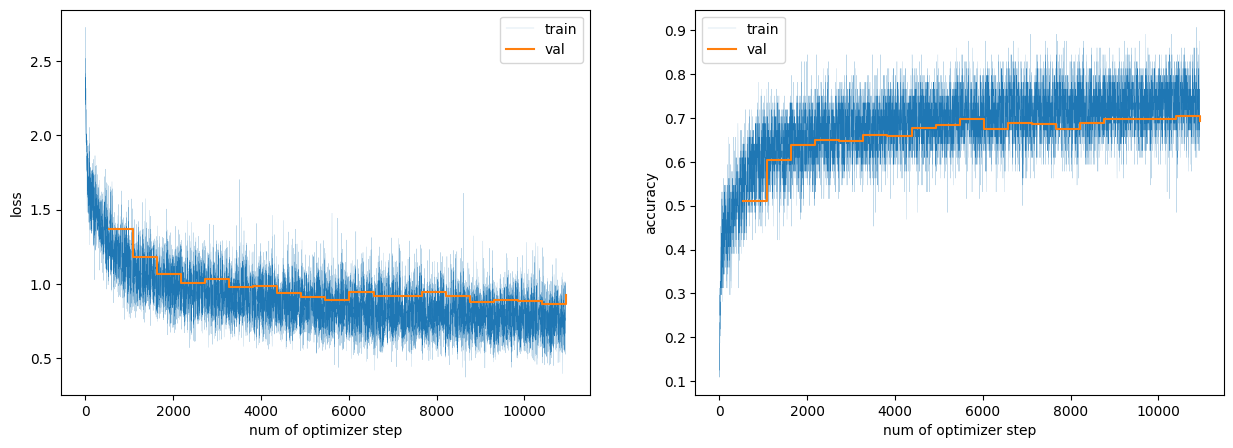

In [17]:
# <your code here>
plot_losses(train_loss_log, train_acc_log, val_loss_log, val_acc_log, train_loader, 20)

## 3. Расписание длины шага (2 балла)

С курса "Машинное обучение 1" вы уже должны знать, что сходимость стохастического градиентного спуска мы можем теоретически гарантировать только если будем определенным образом со временем уменьшать длину шага. На практике при обучении нейронных сетей такая техника оказывается очень полезной, однако теоретически обоснованными способами уменьшения длины шага фантазия не ограничивается.

Одним из простейших способов является кусочно постоянная функция: на нескольких фиксированных эпохах уменьшаем длину шага в константу раз.

In [18]:
net3 = BasicBlockNet().to(device)
optimizer = optim.SGD(net3.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net3, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.476751652997416, train acc: 0.4731979629457324
 val loss: 1.203534609713453, val acc: 0.584264184439436

Epoch 1
 train loss: 1.1621861404431149, train acc: 0.5961249674478004
 val loss: 1.1647358295765329, val acc: 0.5958554965384463

Epoch 2
 train loss: 1.0668110077080386, train acc: 0.6291867981663134
 val loss: 1.1012778365865667, val acc: 0.6139627659574468

Epoch 3
 train loss: 1.0070337852568687, train acc: 0.6491495821985945
 val loss: 1.0566698845396651, val acc: 0.6311170212765957

Epoch 4
 train loss: 0.9713237694238178, train acc: 0.6633422565416619
 val loss: 1.0445197186571487, val acc: 0.6463874114320634

Epoch 5
 train loss: 0.9468440384054096, train acc: 0.6709772460639368
 val loss: 0.9776160519173804, val acc: 0.6600842199427016

Epoch 6
 train loss: 0.9183887662791683, train acc: 0.6792733089579525
 val loss: 0.9512953441193763, val acc: 0.6700797872340426

Epoch 7
 train loss: 0.9032013405393639, train acc: 0.6852311308902622
 val loss: 0.90

Посчитайте точность на тестовой выборке:

In [20]:
# <your code here>
test_loss_log, test_acc_log = test(net3, test_loader)
print(f'test loss: {test_loss_log}')
print(f'test acc: {test_acc_log}')

test loss: 0.8349728569103654
test acc: 0.7150676751592356


Получается, точность на тесте $\approx71.507\%$

**Задание 3.0 (0.5 баллов).** Здесь может возникнуть вопрос: а что будет, если мы не будем уменьшать длину шага в процессе обучения, а сразу возьмем констатную, равную значению нашей кусочно-постоянной функции на последних эпохах, то есть $0.001$ в нашем случае. Запустите обучение и проверьте, что в таком случае мы получим худшее качество на тестовой выборке.

In [21]:
# <your code here>
net_30 = BasicBlockNet().to(device)
optimizer = optim.SGD(net_30.parameters(), lr=0.001, momentum=0.9)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net_30, optimizer, 20, train_loader, val_loader)

Epoch 0
 train loss: 1.7873714011591575, train acc: 0.3750204035307415
 val loss: 1.5621337165223792, val acc: 0.4505540780564572

Epoch 1
 train loss: 1.4978319720332758, train acc: 0.4759810003545646
 val loss: 1.419124708277114, val acc: 0.4968085106382979

Epoch 2
 train loss: 1.3937254339946907, train acc: 0.5089163294222063
 val loss: 1.3482719497477755, val acc: 0.5213652482692231

Epoch 3
 train loss: 1.3359790876970867, train acc: 0.5316213436928702
 val loss: 1.3179993705546602, val acc: 0.5333998227373082

Epoch 4
 train loss: 1.2950126971143692, train acc: 0.5436390049932643
 val loss: 1.273994590881023, val acc: 0.5520168441407224

Epoch 5
 train loss: 1.2547914270291163, train acc: 0.558823289448426
 val loss: 1.251122604278808, val acc: 0.5553413120990104

Epoch 6
 train loss: 1.217991559117542, train acc: 0.57177135026869
 val loss: 1.2026646299565091, val acc: 0.5809840425531915

Epoch 7
 train loss: 1.184317331209479, train acc: 0.5854988248518224
 val loss: 1.2359559

In [22]:
test_loss_log, test_acc_log = test(net_30, test_loader)
print(f'test loss: {test_loss_log}')
print(f'test acc: {test_acc_log}')

test loss: 0.9801245927810669
test acc: 0.6587380573248408


Да, точность на тесте получилась меньше ($\approx65.874\%$).

**Задание 3.1 (1.5 балла).** Изучите, какие еще способы уменьшения длины шага представлены в <code>torch.optim.lr_scheduler</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними. Удалось ли добиться улучшения качества на тестовой выборке?

1. Exponential LR: $\eta_t=\gamma\cdot\eta_{n-1}$ для каждой следующей эпохи lr становится больше в $\gamma$ раз, но по сути уменьшается, так как $\gamma<1$.

Уменьшение происходит плавно, сначала сильнее, а потом слабее. Беру $\gamma=0.95$, так как такое значение в примере использования на сайти с документацией pytorch

In [26]:
# <your code here>
net_311 = BasicBlockNet().to(device)
optimizer = optim.SGD(net_311.parameters(), lr=0.1, momentum=0.9)
scheduler1 = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net_311, optimizer, 20, train_loader, val_loader, scheduler1)

Epoch 0
 train loss: 1.4762646197400973, train acc: 0.4749036955441156
 val loss: 1.2470330438715347, val acc: 0.5598404255319149

Epoch 1
 train loss: 1.149173076017683, train acc: 0.5971369809816699
 val loss: 1.1680248572471295, val acc: 0.5962987590343394

Epoch 2
 train loss: 1.0411983460351362, train acc: 0.6378868504459723
 val loss: 1.035006671763481, val acc: 0.6413342199427017

Epoch 3
 train loss: 0.9688604699628227, train acc: 0.6624322604435672
 val loss: 0.9795943853702951, val acc: 0.6611258866939139

Epoch 4
 train loss: 0.934146910415489, train acc: 0.6783837163905992
 val loss: 0.9554989797003726, val acc: 0.6708333335024246

Epoch 5
 train loss: 0.896983004902137, train acc: 0.6906339775709609
 val loss: 0.9735000668688023, val acc: 0.6646276595744681

Epoch 6
 train loss: 0.8730065558902524, train acc: 0.6965387503887225
 val loss: 0.9658300394707537, val acc: 0.6717420212765958

Epoch 7
 train loss: 0.85357215156067, train acc: 0.7020313724521309
 val loss: 0.89856

In [27]:
test_loss_log, test_acc_log = test(net_311, test_loader)
print(f'test loss: {test_loss_log}')
print(f'test acc: {test_acc_log}')

test loss: 0.8547598915115283
test acc: 0.7088972929936306


Неплохая точность ($\approx70.89\%$), но ниже, чем у MultiStepLR (71.507%)

2. CosineAnnealingLR: $\eta_{t+1} = \eta_{min} + (\eta_t - \eta_{min})\cdot
\frac{1 + \cos\left(\frac{(T_{cur} + 1)\cdot\pi}{T{max}}\right)}{1 + \cos\left(\frac{T{cur}\cdot\pi}{T_{max}}\right)}$

Здесь lr плавно убывает по кривой косинуса и достигает минимального значения в конце обучения. Это дает более плавное уменьшение длины шага, чем ExponentialLR, так как в CosineAnnealingLR вначале не быстро начинает уменьшаться, а медленно, постепенно ускоряясь к концу обучения.


Беру T_max=20, так как в примере использования на сайте документации pytorch T_max=num_epochs

In [28]:
# <your code here>
net_312 = BasicBlockNet().to(device)
optimizer = optim.SGD(net_312.parameters(), lr=0.1, momentum=0.9)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net_312, optimizer, 20, train_loader, val_loader, scheduler2)

Epoch 0
 train loss: 1.5235136161120761, train acc: 0.45745054197921614
 val loss: 1.3312331275737033, val acc: 0.5314716313747649

Epoch 1
 train loss: 1.2027288255787418, train acc: 0.5804632410706724
 val loss: 1.1327114308134039, val acc: 0.6043882978723404

Epoch 2
 train loss: 1.077495565906957, train acc: 0.6269179290565756
 val loss: 1.1185062918257207, val acc: 0.6213874114320633

Epoch 3
 train loss: 1.027802444681171, train acc: 0.646223720401471
 val loss: 1.0571417093276978, val acc: 0.6343971632896586

Epoch 4
 train loss: 0.9765851458422227, train acc: 0.6620935623345036
 val loss: 1.0855134550561296, val acc: 0.6302304965384463

Epoch 5
 train loss: 0.9463817116547328, train acc: 0.6711037477148081
 val loss: 0.9421512258813737, val acc: 0.6760859930768927

Epoch 6
 train loss: 0.9089969131802728, train acc: 0.6839089841467807
 val loss: 0.9641100125109896, val acc: 0.6651595744680852

Epoch 7
 train loss: 0.8889054748650225, train acc: 0.6899402586154135
 val loss: 0.9

In [29]:
test_loss_log, test_acc_log = test(net_312, test_loader)
print(f'test loss: {test_loss_log}')
print(f'test acc: {test_acc_log}')

test loss: 0.8261004576257839
test acc: 0.716859076433121


Получилась точность на тесте $\approx71.686\%$, что немного выше, чем у MultiStepLR (71.507%)

3. CyclicLR задаёт lr в виде периодически повторяющегося цикла (в одном цикле lr сначала увеличивается от base_lr до max_lr, а потом уменьшается обратно)

Плюс в том, что благодаря этому lr можно будет выйти из локального минимума, если зайдем в него.

In [30]:
# <your code here>
net_313 = BasicBlockNet().to(device)
optimizer = optim.SGD(net_313.parameters(), lr=0.1, momentum=0.9)
scheduler3 = optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.01, max_lr=0.1, step_size_up=10)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net_313, optimizer, 20, train_loader, val_loader, scheduler3)

Epoch 0
 train loss: 1.5228393182458129, train acc: 0.4524720881059357
 val loss: 1.3086599504694025, val acc: 0.5347296099713508

Epoch 1
 train loss: 1.2648884185489397, train acc: 0.5503191107805729
 val loss: 1.2015714031584719, val acc: 0.5792109930768926

Epoch 2
 train loss: 1.1127787207336706, train acc: 0.6082446461839693
 val loss: 1.0723484041843008, val acc: 0.6243572696726373

Epoch 3
 train loss: 1.0323428227217148, train acc: 0.6386540219378428
 val loss: 1.00342587841318, val acc: 0.6504875888215734

Epoch 4
 train loss: 0.9813622940175059, train acc: 0.6592574759200897
 val loss: 1.0080940634646314, val acc: 0.648847517815042

Epoch 5
 train loss: 0.949722478224111, train acc: 0.6707609689213894
 val loss: 0.968981080359601, val acc: 0.6626994680851064

Epoch 6
 train loss: 0.9176701481643063, train acc: 0.6794895861004998
 val loss: 0.93822692962403, val acc: 0.6726285461415635

Epoch 7
 train loss: 0.901023328849123, train acc: 0.689899451662897
 val loss: 0.98541804

In [31]:
test_loss_log, test_acc_log = test(net_313, test_loader)
print(f'test loss: {test_loss_log}')
print(f'test acc: {test_acc_log}')

test loss: 0.8241929482122895
test acc: 0.723328025477707


Получилась точность на тесте $\approx72.333\%$, что выше, чем у MultiStepLR (71.507%) и у предыдущего CosineAnnealingLR (71.686%)

Но в целом у всех lr лучше бейзлайна, который чуть больше 67%

## 4. Аугментации данных (2 балла)

Еще одной стандартной техникой, применяющейся в глубинном обучении, а особенно часто в компьютерном зрении, являются аугментации данных. Суть аугментаций состоит в том, что мы можем некоторым синтетическим образом видоизменять объекты обучающей выборки, тем самым расширяя ее, а также делая итоговую модель более устойчивой к таким изменениям.

Простейшая аугментация, которую можно применить к картинкам — разворот картинки по горизонтальной оси. То есть при обучении модели с вероятностью $0.5$ мы будем разворачивать картинку из обучающей выборки.

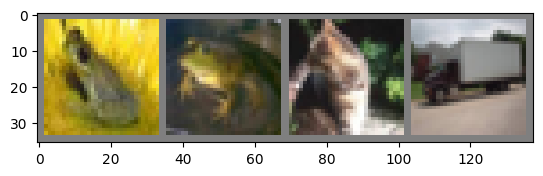

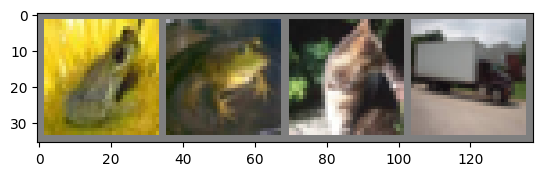

In [33]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))

imshow(torchvision.utils.make_grid(transforms.functional.hflip(images[:4])))

Наиболее удобным способом работы с аугментациями в PyTorch является их задание в списке <code>transforms</code>, который затем передается в загрузчик данных. Обучим нашу сеть, применяя горизонтальные повороты:

In [34]:
transform = transforms.Compose(
        [transforms.RandomHorizontalFlip(),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net_4 = BasicBlockNet().to(device)
optimizer = optim.SGD(net_4.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net_4, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.4860620535705817, train acc: 0.47059855709564097
 val loss: 1.2884244708304708, val acc: 0.5374335106382979

Epoch 1
 train loss: 1.1902603359937232, train acc: 0.5803326587354461
 val loss: 1.1155204351912154, val acc: 0.6089095744680851

Epoch 2
 train loss: 1.0600485009510732, train acc: 0.6283584160822183
 val loss: 1.0720316841247235, val acc: 0.6247783688788718

Epoch 3
 train loss: 1.000258763158997, train acc: 0.6521448159566527
 val loss: 0.974239574087427, val acc: 0.6612810284533399

Epoch 4
 train loss: 0.9605034064549197, train acc: 0.6655825607519481
 val loss: 1.0065695914816348, val acc: 0.649312943346957

Epoch 5
 train loss: 0.9242139088170402, train acc: 0.6765882084095064
 val loss: 0.9396405805932715, val acc: 0.667220744680851

Epoch 6
 train loss: 0.9075033568812898, train acc: 0.6883447049304816
 val loss: 0.9283659770133648, val acc: 0.6787677305809995

Epoch 7
 train loss: 0.8943818773277499, train acc: 0.6903320058390253
 val loss: 0.89

Посчитайте точность на тестовой выборке:

In [35]:
# <your code here>
test_loss_log, test_acc_log = test(net_4, test_loader)
print(f'test loss: {test_loss_log}')
print(f'test acc: {test_acc_log}')

test loss: 0.8007207630546229
test acc: 0.7264132165605095


Точность на тесте $\approx72.641\%$

**Задание 4.1 (2 балла).** Изучите, какие еще способы аугментаций изображений представлены в <code>torchvision.transforms</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними (по отдельности и вместе). Удалось ли добиться улучшения качества на тестовой выборке?

1. RandomCrop случайно вырезает часть изображения заданного размера (если передаем число, то квадрат, если кортеж из двух чисел, то прямоугольник), также есть параметр padding, он добавляет пикселей перед обрезкой. Я беру параметры (32, padding=5), то есть увеличу до 42x42 и потом вырежу такого же размера, как и было

In [36]:
# <your code here>
transform = transforms.Compose(
        [transforms.RandomCrop(32, padding=5),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net_411 = BasicBlockNet().to(device)
optimizer = optim.SGD(net_411.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net_411, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.7082916315120578, train acc: 0.3793663489317327
 val loss: 1.5326989549271604, val acc: 0.44388297872340426

Epoch 1
 train loss: 1.4660981010911234, train acc: 0.47192478463244397
 val loss: 1.3929094720394053, val acc: 0.5059840425531915

Epoch 2
 train loss: 1.3278264755304814, train acc: 0.5248881888999799
 val loss: 1.2659996222942433, val acc: 0.5516179079705096

Epoch 3
 train loss: 1.2550196555022566, train acc: 0.5541345652540162
 val loss: 1.3057319542194934, val acc: 0.5388962765957447

Epoch 4
 train loss: 1.199429400115388, train acc: 0.5782841473436443
 val loss: 1.3035491436085802, val acc: 0.5503546100981692

Epoch 5
 train loss: 1.167223090554504, train acc: 0.5869148276623686
 val loss: 1.1887918451999095, val acc: 0.5810505319148936

Epoch 6
 train loss: 1.1416445116238358, train acc: 0.5986917276051188
 val loss: 1.163754297824616, val acc: 0.5900044327086591

Epoch 7
 train loss: 1.1177040150004287, train acc: 0.6058125490462323
 val loss: 1.

In [37]:
# <your code here>
test_loss_log, test_acc_log = test(net_411, test_loader)
print(f'test loss: {test_loss_log}')
print(f'test acc: {test_acc_log}')

test loss: 0.8628968509139529
test acc: 0.7029259554140127


Точность на тесте $\approx70.293\%$ - хуже, чем RandomHorizontalFlip

2. ColorJitter случайно меняет следующие характеристики изображения: яркость (изменяется случайно в диапазоне [1 - brightness, 1 + brightness]), контраст (изменяется случайно в диапазоне [1 - contrast, 1 + contrast]), насыщенность (изменяется случайно в диапазоне [1 - saturation, 1 + saturation]), оттенок (изменяется случайно в диапазоне [-hue, hue])

In [40]:
# <your code here>
transform = transforms.Compose(
        [transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net_412 = BasicBlockNet().to(device)
optimizer = optim.SGD(net_412.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net_412, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.5330161015337955, train acc: 0.45505925179399564
 val loss: 1.3359372275940915, val acc: 0.5243572695458188

Epoch 1
 train loss: 1.2128160798571446, train acc: 0.5753093171163276
 val loss: 1.1972830128162466, val acc: 0.5871453901554676

Epoch 2
 train loss: 1.107547108281465, train acc: 0.6128599177330896
 val loss: 1.0691602443126922, val acc: 0.6312721632896585

Epoch 3
 train loss: 1.0505375653995674, train acc: 0.6367564965209752
 val loss: 1.1184408999503928, val acc: 0.6187278369639783

Epoch 4
 train loss: 1.0125868628840125, train acc: 0.6508226691042047
 val loss: 1.0991776945743155, val acc: 0.6189716312479465

Epoch 5
 train loss: 0.9815334809545625, train acc: 0.6599022264454439
 val loss: 1.000987031865627, val acc: 0.6577127659574468

Epoch 6
 train loss: 0.9599109266968052, train acc: 0.6680636263198783
 val loss: 0.971904970483577, val acc: 0.6650265957446808

Epoch 7
 train loss: 0.9432018549612279, train acc: 0.675074268738574
 val loss: 1.02

In [41]:
# <your code here>
test_loss_log, test_acc_log = test(net_412, test_loader)
print(f'test loss: {test_loss_log}')
print(f'test acc: {test_acc_log}')

test loss: 0.8376692727113225
test acc: 0.7133757961783439


Точность на тесте $\approx71.338\%$ - лучше RandomCrop, но хуже, чем RandomHorizontalFlip

3. RandomRotation случайно поворачивает изображение на угол из диапазона [-degrees, degrees]

In [42]:
# <your code here>
transform = transforms.Compose(
        [transforms.RandomRotation(degrees=15),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net_413 = BasicBlockNet().to(device)
optimizer = optim.SGD(net_413.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net_413, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.548179938108873, train acc: 0.44392710237659966
 val loss: 1.3363528627030392, val acc: 0.5156693263256803

Epoch 1
 train loss: 1.276471587705002, train acc: 0.5475075085812556
 val loss: 1.1685285527655418, val acc: 0.5865026595744681

Epoch 2
 train loss: 1.161762926434686, train acc: 0.5927951162650337
 val loss: 1.10507940434395, val acc: 0.6126994680851063

Epoch 3
 train loss: 1.0963823289714305, train acc: 0.6147574432589237
 val loss: 1.060958306332852, val acc: 0.6283023050490846

Epoch 4
 train loss: 1.0514561163442009, train acc: 0.6299702925045704
 val loss: 1.0592737076130319, val acc: 0.6260195037151904

Epoch 5
 train loss: 1.0198842755619306, train acc: 0.6446771350377657
 val loss: 1.0461320623438408, val acc: 0.6341755319148936

Epoch 6
 train loss: 0.9961015985260498, train acc: 0.6505574236404308
 val loss: 0.9832724756382881, val acc: 0.6553413122258288

Epoch 7
 train loss: 0.9853113109494476, train acc: 0.6520999282108146
 val loss: 0.9765

In [43]:
# <your code here>
test_loss_log, test_acc_log = test(net_413, test_loader)
print(f'test loss: {test_loss_log}')
print(f'test acc: {test_acc_log}')

test loss: 0.822861802046466
test acc: 0.7177547770700637


Точность на тесте $\approx71.775\%$ - самый лучший из трех мною выбранных, но все равно хуже, чем RandomHorizontalFlip

Но в целом у всех аугментаций лучше бейзлайна, который чуть больше 67%

## Бонус. Логирование в comet (2 балла)

На практике специалиста по глубинному обучению часто встречаются ситуации, когда нейросеть учится на каком-то удаленном сервере. И обычно вам хочется отслеживать прогресс обучения, особенно когда время обучения модели исчисляется днями или неделями. Для таких целей существует несколько инструментов. ~~Вероятно, самый популярный из них — [wandb](https://wandb.ai/site)~~ Например: [TensorBoard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html), [comet](https://www.comet.com), [wandb](https://wandb.ai/). Выберите любой удобный из них.

Ваша задача состоит в том, чтобы разобраться как им пользоваться, и повторить задания 2.1 и 2.2 с его использованием. Обучение вы можете запускать в этом же ноутбуке, но теперь вам необходимо логировать значения функции потерь и точности на обучающей выборке и на валидационной. Результатом работы должны быть ваш код, публичная ссылка на страничку с графиками, идентичными графикам в задании 2.2 или выхлоп тензорбоард.

In [44]:
pip install comet-ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.0/780.0 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.9 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.3.2
    Uninstalling python-box-7.3.2:
      Successfully uninstalled python-box-7.3.2


In [51]:
# <your code here>
from comet_ml import Experiment

Переделал функции, чтобы использовать логирование в comet

После выполнения ячейки удалил api_key

In [62]:
def test_log(model, loader, exp, global_step):
    loss_log = []
    acc_log = []
    model.eval()

    with torch.no_grad():
      for data, target in loader:
          data = data.to(device)
          target = target.to(device)
          # <your code here>
          logits = model(data)
          loss_val = F.cross_entropy(logits, target).item()
          loss_log.append(loss_val)

          # <your code here>
          predicts = logits.argmax(dim=1)
          corr_preds = (predicts == target).float()
          acc_val = corr_preds.mean().item()
          acc_log.append(acc_val)

    mean_loss = np.mean(loss_log)
    mean_acc = np.mean(acc_log)

    exp.log_metric('val_loss', mean_loss, step=global_step)
    exp.log_metric('val_acc', mean_acc, step=global_step)

    return mean_loss, mean_acc

def train_epoch_log(model, optimizer, train_loader, exp, global_step):
    loss_log = []
    acc_log = []
    model.train()

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)
        # <your code here>
        optimizer.zero_grad()
        logits = model(data)
        loss = F.cross_entropy(logits, target)
        loss.backward()
        optimizer.step()
        loss_val = loss.item()
        exp.log_metric('train_loss', loss_val, step=global_step)
        loss_log.append(loss_val)

        # <your code here>
        predicts = logits.argmax(dim=1)
        corr_preds = (predicts == target).float()
        acc = corr_preds.mean()
        acc_val = acc.item()
        exp.log_metric('train_acc', acc_val, step=global_step)
        acc_log.append(acc_val)

        global_step += 1

    return loss_log, acc_log, global_step

def train_log(model, optimizer, n_epochs, train_loader, val_loader, exp, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []
    global_step = 0

    for epoch in range(n_epochs):
        train_loss, train_acc, global_step = train_epoch_log(model, optimizer, train_loader, exp, global_step)
        val_loss, val_acc = test_log(model, val_loader, exp, global_step)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")

        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

In [63]:
exp = Experiment(api_key='', project_name='classification_of_cifar10', workspace='nikita-nazarov')

net_5 = BasicBlockNet().to(device)
optimizer = optim.SGD(net_5.parameters(), lr=0.1, momentum=0.9)

train_loss_log, train_acc_log, val_loss_log, val_acc_log = train_log(net_5, optimizer, 20, train_loader, val_loader, exp)
exp.end()

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/nikita-nazarov/classification-of-cifar10/fb650e4a64914fe8bbef3ce86e3c9078



Epoch 0
 train loss: 1.553472756685679, train acc: 0.4431558500914077
 val loss: 1.414310689682656, val acc: 0.4945700355032657

Epoch 1
 train loss: 1.2989240974133367, train acc: 0.5397990664136911
 val loss: 1.2182158698426917, val acc: 0.5668218085106383

Epoch 2
 train loss: 1.1882241912036318, train acc: 0.5789493013997401
 val loss: 1.1773981588952085, val acc: 0.5832225178150421

Epoch 3
 train loss: 1.115476341853412, train acc: 0.6092933860949667
 val loss: 1.132755884211114, val acc: 0.6050088654173181

Epoch 4
 train loss: 1.074738450089582, train acc: 0.6246000914076782
 val loss: 1.1207860469818116, val acc: 0.6131427305809996

Epoch 5
 train loss: 1.041471501155135, train acc: 0.635099732352785
 val loss: 1.0619593749655054, val acc: 0.6239140071767442

Epoch 6
 train loss: 1.017269107933672, train acc: 0.6447465069987003
 val loss: 1.0055386588928548, val acc: 0.6474512412192973

Epoch 7
 train loss: 0.993575867503827, train acc: 0.6504635675733661
 val loss: 0.97938838

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : accused_subdivision_8613
COMET INFO:     url                   : https://www.comet.com/nikita-nazarov/classification-of-cifar10/fb650e4a64914fe8bbef3ce86e3c9078
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     train_acc [10940]  : (0.0625, 0.875)
COMET INFO:     train_loss [10940] : (0.4673927426338196, 2.4399361610412598)
COMET INFO:     val_acc [20]       : (0.4945700355032657, 0.6836657803109352)
COMET INFO:     val_loss [20]      : (0.9206967830657959, 1.414310689682656)
COMET INFO:   Others:
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=1zxvHPXExnwiyaK1WHWatR0oUGtvbKoVb
COMET INFO:   Uploads:
COMET INF

Ссылка на графики: https://www.comet.com/nikita-nazarov/classification-of-cifar10/fb650e4a64914fe8bbef3ce86e3c9078